# C08 · Mauna Loa CO2: a forecast that knows what it does not know

| | |
|---|---|
| **Difficulty** | ★★★★☆ |
| **Time** | 4-5 hours |
| **Data** | NOAA Global Monitoring Laboratory, monthly mean CO2 at Mauna Loa, March 1958 to the present |
| **Skills** | Structural time-series models from GP building blocks · `pm.gp.HSGP` as a model component · why stationary kernels cannot extrapolate a trend · identifiability between additive components and how priors restore it · honest hold-out evaluation (RMSE, interval coverage, baselines) · turning a posterior predictive into a "when will it cross" answer |

## The brief

A climate-policy analyst is preparing a briefing. Two numbers will go on the first slide:

1. **When will the monthly mean CO2 concentration at Mauna Loa first exceed 450 ppm?** Not
   a single date - a distribution she can quote as "most likely X, almost certainly by Y".
2. **How fast is CO2 rising now, compared with the 1960s?** In ppm per year, with uncertainty.

She has been burned before by forecasts with error bars that turned out to be decorative.
So before she trusts your answer you must show that your model, fitted **without the last
ten years**, would have forecast those ten years well - and that its intervals meant what
they said.

This is the most famous time series in climate science and it looks easy: a smooth rise
with a seasonal wiggle. The obvious GP model for it has a flaw that a ten-year hold-out
barely exposes, and the model that fixes the flaw will not sample until you think hard
about which component is allowed to explain what.

## How this notebook works

- Each task states **what to deliver**, not how. Write your code in the `YOUR CODE HERE` cells.
- Stuck? `h.hint("task3")` reveals hints one level at a time: *nudge → approach → code skeleton*.
- `h.check("task5", rmse=...)` compares your numbers with the reference solution.
- A full worked solution lives in `notebooks/solutions/`. Open it only when you are done.
- Assumes you have worked through **E05** (GPs and HSGP).

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import pytensor.tensor as pt
from pymc.model.transform.optimization import freeze_dims_and_data

from pymc_challenges import Hints, data

RANDOM_SEED = 1958
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

h = Hints("C08")
h.tasks()

**C08 - Mauna Loa CO2: a forecast that knows what it does not know**

- `task0` - Decompose it by eye (3 hints, 2 check(s))
- `task1` - Hold out ten years and set the bar (3 hints, 2 check(s))
- `task2` - The obvious GP (3 hints, 2 check(s))
- `task3` - A structural model, first attempt (3 hints)
- `task4` - Tame it with priors (3 hints, 2 check(s))
- `task5` - Hold-out evaluation (3 hints, 2 check(s))
- `task6` - Answer the analyst (3 hints, 3 check(s))

## The data

One row per month. `average` is the monthly mean in ppm and `decimal date` is the middle
of the month as a fractional year. `deseasonalized` is NOAA's own seasonal adjustment - you
may look at it, but your model must work from `average`. NOAA files use negative numbers
as missing-value codes; find out which columns are affected before you trust any of them.

In [2]:
data.describe("co2")
co2 = data.load("co2").rename(columns={"decimal date": "t", "average": "ppm"})
co2.tail()

co2: Monthly mean atmospheric CO2 (ppm) from March 1958 to the present.
  source: NOAA Global Monitoring Laboratory, Mauna Loa monthly mean CO2.
  url:    https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv


,year,month,t,ppm,deseasonalized,ndays,sdev,unc
817,2026,4,2026.2917,431.12,428.61,23,1.16,0.46
818,2026,5,2026.3750,432.34,429.06,19,0.64,0.28
819,2026,6,2026.4583,431.43,428.99,19,0.27,0.12
820,2026,7,2026.5417,429.13,428.78,21,0.61,0.26
821,2026,8,2026.6250,427.55,429.51,17,0.36,0.17


In [3]:
THRESHOLD = 450.0  # ppm
N_TEST = 120  # months held out: the last ten years

## Task 0 · Decompose it by eye

**Deliver**
1. A check for missing-value codes. Is `ppm` affected?
2. A plot of the full series, and a close-up of a few years that shows the seasonal cycle.
3. The average seasonal profile (12 numbers) after removing the trend in a simple,
   model-free way. In which month does CO2 peak, and what is the peak-to-trough range?
   Is that range the same in the 1960s and the 2010s?
4. A rough growth rate (ppm/yr) per decade from annual means. This is the sanity check for
   everything your model says later.

In [4]:
print("rows with a negative value, by column:")
print((co2.drop(columns="t") < 0).sum().to_string())
print(f"\n{len(co2)} months, {co2.year.iloc[0]}-{co2.month.iloc[0]:02d} to "
      f"{co2.year.iloc[-1]}-{co2.month.iloc[-1]:02d}; latest value {co2.ppm.iloc[-1]} ppm")

rows with a negative value, by column:
year                0
month               0
ppm                 0
deseasonalized      0
ndays             195
sdev              196
unc               194

822 months, 1958-03 to 2026-08; latest value 427.55 ppm


The missing codes (`-1`, `-9.99`, `-0.99`) only affect the quality columns `ndays`, `sdev`
and `unc` before the mid-1970s. `ppm` is complete: NOAA has already interpolated the few
months in which the observatory was down. Nothing to clean, but now we *know* that.

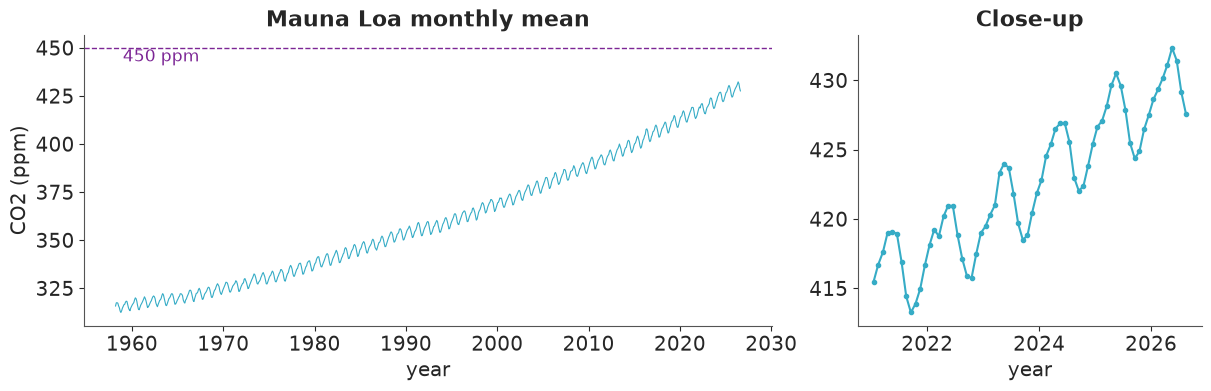

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(co2.t, co2.ppm, lw=0.8)
axes[0].axhline(THRESHOLD, color="C3", ls="--", lw=1)
axes[0].text(1959, THRESHOLD - 7, "450 ppm", color="C3")
axes[0].set(xlabel="year", ylabel="CO2 (ppm)", title="Mauna Loa monthly mean")
recent = co2[co2.t >= 2021]
axes[1].plot(recent.t, recent.ppm, "o-", ms=3)
axes[1].set(xlabel="year", title="Close-up");

peak month: 5 (+3.11 ppm), trough month: 10 (-3.18 ppm), range: 6.29 ppm
range by era: {'1960s': 5.97, '2010s': 6.89}

mean annual increase by decade (ppm/yr):
year
1960    0.86
1970    1.22
1980    1.64
1990    1.53
2000    1.91
2010    2.40
2020    2.62


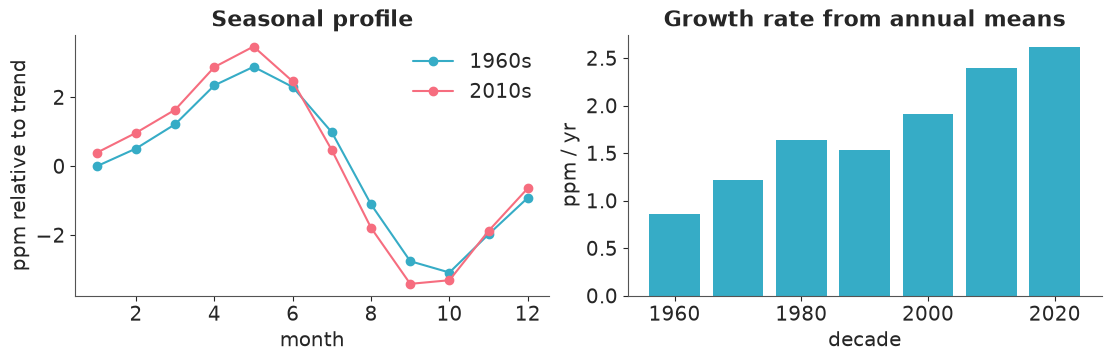

In [6]:
# model-free detrending: subtract a centred 12-month moving average
detrended = co2.ppm - co2.ppm.rolling(12, center=True).mean()
profile = detrended.groupby(co2.month).mean()
by_era = pd.DataFrame({
    "1960s": detrended[co2.year.between(1960, 1969)].groupby(co2.month).mean(),
    "2010s": detrended[co2.year.between(2010, 2019)].groupby(co2.month).mean(),
})
peak_month = int(profile.idxmax())
seasonal_range = float(profile.max() - profile.min())
print(f"peak month: {peak_month} ({profile.max():+.2f} ppm), trough month: {int(profile.idxmin())} "
      f"({profile.min():+.2f} ppm), range: {seasonal_range:.2f} ppm")
print("range by era:", (by_era.max() - by_era.min()).round(2).to_dict())

annual = co2.groupby("year").ppm.mean()
growth = annual.diff()
decade_growth = growth.groupby((growth.index // 10) * 10).mean().loc[1960:2020]
print("\nmean annual increase by decade (ppm/yr):")
print(decade_growth.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
by_era.plot(ax=axes[0], marker="o")
axes[0].set(xlabel="month", ylabel="ppm relative to trend", title="Seasonal profile")
axes[1].bar(decade_growth.index, decade_growth.values, width=8)
axes[1].set(xlabel="decade", ylabel="ppm / yr", title="Growth rate from annual means");

In [7]:
assert h.check("task0", peak_month=peak_month, seasonal_range=seasonal_range)

- PASS `peak_month` = 5 is consistent with the reference solution.
- PASS `seasonal_range` = 6.289 is consistent with the reference solution.

Three components, visible to the naked eye:

- a **trend** that is not a straight line: the growth rate has roughly tripled since the 1960s;
- a **seasonal cycle** of about 6 ppm peak to trough, peaking in May (northern-hemisphere
  plants have not yet started drawing CO2 down) - and it is *larger* now than in the 1960s;
- whatever is left: year-to-year irregularities (El Niño years grow faster) and noise.

Note the scales. The trend spans more than 100 ppm, the seasonal cycle 6 ppm, the rest well
under 1 ppm. And 450 ppm is only about 20 ppm above today's level: whether a given month
crosses it depends on the *seasonal* position as much as on the trend.

## Task 1 · Hold out ten years and set the bar

Split off the last `N_TEST` months as a test set. You may not touch it for fitting until
Task 6.

A model is only interesting if it beats something trivial. **Deliver** the hold-out RMSE of
two baselines:

- *seasonal naive*: every future month equals the same calendar month in the last training year;
- *seasonal naive with drift*: the same, plus `k` times the average annual increase over the
  last ten training years for a month that lies `k` years (1, 2, ...) after its source month.
  Measure the increase as the change in the 12-month mean between the last training year and
  the year ending ten years before it, divided by ten.

In [8]:
train, test = co2.iloc[:-N_TEST], co2.iloc[-N_TEST:]
print(f"train: {train.t.iloc[0]:.2f} - {train.t.iloc[-1]:.2f} ({len(train)} months)")
print(f"test:  {test.t.iloc[0]:.2f} - {test.t.iloc[-1]:.2f} ({len(test)} months)")

train: 1958.20 - 2016.62 (702 months)
test:  2016.71 - 2026.62 (120 months)


In [9]:
def rmse(forecast):
    return float(np.sqrt(np.mean((test.ppm.to_numpy() - forecast) ** 2)))


last_year = train.ppm.to_numpy()[-12:]
years_ahead = np.arange(N_TEST) // 12 + 1
drift = (train.ppm.to_numpy()[-12:].mean() - train.ppm.to_numpy()[-132:-120].mean()) / 10

naive = last_year[np.arange(N_TEST) % 12]
naive_drift = naive + drift * years_ahead
scores = {"seasonal naive": rmse(naive), "seasonal naive + drift": rmse(naive_drift)}
print(f"drift = {drift:.2f} ppm/yr")
pd.Series(scores, name="hold-out RMSE (ppm)").round(2)

drift = 2.19 ppm/yr


seasonal naive            15.52
seasonal naive + drift     2.06
Name: hold-out RMSE (ppm), dtype: float64

In [10]:
assert h.check("task1", rmse_naive=scores["seasonal naive"], rmse_drift=scores["seasonal naive + drift"])

- PASS `rmse_naive` = 15.52 is consistent with the reference solution.
- PASS `rmse_drift` = 2.064 is consistent with the reference solution.

The pure seasonal-naive forecast is a straw man - it ignores the trend and is off by more
than 20 ppm after ten years. The drift version is the real bar: about **2 ppm** RMSE over
a decade from two lines of NumPy. It has no uncertainty, though, and that is what the
analyst is paying for.

## Task 2 · The obvious GP

E05 showed that a GP with a stationary kernel is a wonderful smoother. Use one as a
forecaster: a **single stationary kernel plus Gaussian noise**, fitted to the training data,
nothing else. Use `pm.gp.HSGP` and make sure the approximation is valid over the whole range
you will predict on.

> **Performance note (not a modelling hint).** When the inputs of an HSGP are a `pm.Data`
> container, the sine basis is recomputed at *every gradient evaluation*. Sample inside
> `with freeze_dims_and_data(model):` (imported above) to turn the data into constants for
> sampling; keep using the original `model` with `pm.set_data` for prediction. In this
> notebook it is the difference between one minute and half an hour.

**Deliver**
1. The fit, with diagnostics. Compare the posterior lengthscale with the length of the
   record. What is the model trying to tell you?
2. A forecast plot over the hold-out period with a 90% predictive band - and the same
   forecast **extended to 2060**.
3. Hold-out RMSE and 90% coverage, next to the baselines.
4. A short paragraph: what does the forecast do far from the data, and why would *any*
   stationary kernel do the same, whatever its hyperparameters? What does the noise term
   `sigma` represent in this model?

### Solution

Time is measured in years since 1990 and CO2 is centred on the training mean, so the GP's
zero mean function is "the average level of the record". Priors: the amplitude must cover
a rise of ~100 ppm (`HalfNormal(50)`); the noise term is generous (`HalfNormal(5)`); the
lengthscale gets the E05 treatment - little mass below 2 years or above 30 years, half the
record, since anything longer is indistinguishable from a low-order polynomial.

`m` and `L` come from the PyMC heuristic, fed with the range we will *predict* on (to 2060),
not just the training range. The data pin the function down tightly, so we use the centred
parametrisation (E05, section 6).

In [11]:
T0 = 1990.0
PPM_MEAN = train.ppm.mean()
T_END_LONG = 2060.0


def to_x(t):
    """Decimal year -> model input (years since T0), as a column."""
    return (np.asarray(t, dtype=float) - T0)[:, None]


ell_stat_prior = pz.maxent(pz.InverseGamma(), lower=2, upper=30, mass=0.9, plot=False)
m_stat, c_stat = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[train.t.min() - T0, T_END_LONG - T0], lengthscale_range=[5, 30], cov_func="matern52"
)
L_stat = c_stat * (T_END_LONG - train.t.min()) / 2
print(f"lengthscale prior: {ell_stat_prior};  m = {m_stat}, c = {c_stat:.2f}, L = {L_stat:.0f} years")

with pm.Model(coords={"obs": train.t.to_numpy()}) as gp_model:
    X = pm.Data("X", to_x(train.t), dims=("obs", "feature"))
    ell = pm.InverseGamma("ell", alpha=float(ell_stat_prior.alpha), beta=float(ell_stat_prior.beta))
    eta = pm.HalfNormal("eta", 50)
    sigma = pm.HalfNormal("sigma", 5)
    gp = pm.gp.HSGP(m=[m_stat], L=[L_stat], parametrization="centered",
                    cov_func=eta**2 * pm.gp.cov.Matern52(1, ls=ell))
    f = gp.prior("f", X=X, dims="obs")
    pm.Normal("y", f, sigma, observed=train.ppm.to_numpy() - PPM_MEAN, dims="obs", shape=f.shape)

with freeze_dims_and_data(gp_model):
    gp_idata = pm.sample(random_seed=RANDOM_SEED)

print("divergences:", int(gp_idata.sample_stats["diverging"].sum()))
az.summary(gp_idata, var_names=["ell", "eta", "sigma"], ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [eta, ell, f_hsgp_coeffs, sigma]


lengthscale prior: InverseGamma(alpha=2.52, beta=24.5);  m = 65, c = 2.42, L = 123 years


divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
ell,60.24,16.12,32.69,91.80,97.96,250.27,1.04,1.61,0.69
eta,59.33,22.18,23.51,99.65,439.17,802.26,1.01,0.97,0.49
sigma,2.15,0.06,2.04,2.26,5901.19,2883.85,1.00,0.00,0.00


In [12]:
def predict(model, idata, t_new, var_names):
    """Posterior predictive at new times, as {name: array (draws, len(t_new))} in ppm."""
    with model:
        pm.set_data({"X": to_x(t_new)}, coords={"obs": np.asarray(t_new)})
        pred = pm.sample_posterior_predictive(
            idata, var_names=var_names, predictions=True, random_seed=RANDOM_SEED, progressbar=False
        )
    return {v: pred.predictions[v].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()
            for v in var_names}


def holdout_scores(y_draws):
    """RMSE of the predictive mean and coverage of the central 50% / 90% intervals on the test set."""
    obs = test.ppm.to_numpy()
    out = {"RMSE": rmse(y_draws.mean(axis=0))}
    for prob in (0.5, 0.9):
        lo, hi = np.quantile(y_draws, [(1 - prob) / 2, (1 + prob) / 2], axis=0)
        out[f"coverage {prob:.0%}"] = float(((obs >= lo) & (obs <= hi)).mean())
        out[f"width {prob:.0%} at 10 yr"] = float((hi - lo)[-12:].mean())
    return out


t_long = np.arange(test.t.iloc[0], T_END_LONG, 1 / 12)
gp_pred = predict(gp_model, gp_idata, t_long, ["y", "f"])
gp_y = gp_pred["y"] + PPM_MEAN
gp_scores = holdout_scores(gp_y[:, :N_TEST])

Sampling: [y]


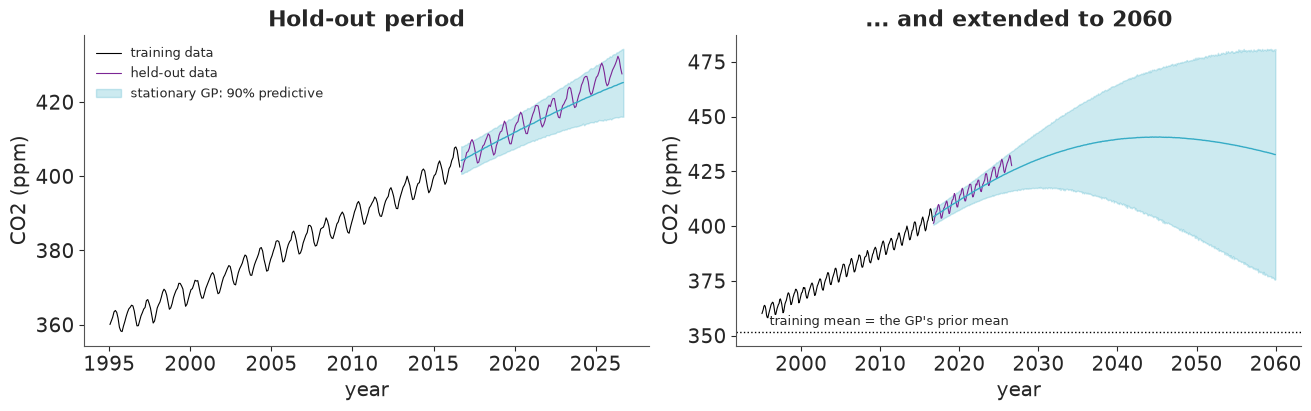

In [13]:
def plot_forecast(t_new, y_draws, ax, color="C0", label=None):
    lo, hi = np.quantile(y_draws, [0.05, 0.95], axis=0)
    ax.fill_between(t_new, lo, hi, color=color, alpha=0.25, label=f"{label}: 90% predictive")
    ax.plot(t_new, y_draws.mean(axis=0), color=color, lw=1)


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, t_max in zip(axes, [test.t.iloc[-1] + 0.1, T_END_LONG]):
    keep = t_long <= t_max
    ax.plot(train.t[train.t > 1995], train.ppm[train.t > 1995], color="k", lw=0.8, label="training data")
    ax.plot(test.t, test.ppm, color="C3", lw=0.8, label="held-out data")
    plot_forecast(t_long[keep], gp_y[:, keep], ax, label="stationary GP")
    ax.set(xlabel="year", ylabel="CO2 (ppm)")
axes[0].set_title("Hold-out period")
axes[1].set_title("... and extended to 2060")
axes[1].axhline(PPM_MEAN, color="k", ls=":", lw=1)
axes[1].text(1996, PPM_MEAN + 3, "training mean = the GP's prior mean", fontsize=9)
axes[0].legend(fontsize=9);

In [14]:
i_peak = int(gp_pred["f"].mean(axis=0).argmax())
print(f"the mean forecast peaks in {t_long[i_peak]:.0f} at {gp_pred['f'].mean(axis=0)[i_peak] + PPM_MEAN:.0f} ppm, "
      f"then falls to {gp_pred['f'].mean(axis=0)[-1] + PPM_MEAN:.0f} ppm by {T_END_LONG:.0f}")
score_table = pd.DataFrame({"seasonal naive": {"RMSE": scores["seasonal naive"]},
                            "seasonal naive + drift": {"RMSE": scores["seasonal naive + drift"]},
                            "stationary GP": gp_scores}).T
score_table.round(2)

the mean forecast peaks in 2045 at 441 ppm, then falls to 433 ppm by 2060


,RMSE,coverage 50%,width 50% at 10 yr,coverage 90%,width 90% at 10 yr
seasonal naive,15.52,NaN,NaN,NaN,NaN
seasonal naive + drift,2.06,NaN,NaN,NaN,NaN
stationary GP,3.19,0.46,6.7,0.97,17.23


In [15]:
assert h.check("task2", sigma=gp_idata.posterior["sigma"].mean(), rmse=gp_scores["RMSE"])

- PASS `sigma` = 2.147 is consistent with the reference solution.
- PASS `rmse` = 3.191 is consistent with the reference solution.

Read this carefully, because the failure is quieter than you might expect.

**On the ten-year hold-out the stationary GP is not a disaster - it is merely bad.** Its
RMSE is worse than the two-line drift baseline, and it achieves its coverage with a band
that is about 17 ppm wide after ten years: nearly the whole distance between today and
450 ppm. There is also no seasonal cycle in the forecast. A single kernel cannot be both
smooth enough for the trend and wiggly enough for the seasons, so it chose the trend and
called the seasonal cycle noise: `sigma` is about 2 ppm, which is the standard deviation of
a 6 ppm peak-to-trough cycle, not measurement error.

**The extended forecast shows the real problem.** The mean curve bends over, peaks and
*comes back down* towards the training mean. Nobody believes that. The reason is built into
the word *stationary*: the kernel depends only on $|t - t'|$, so the prior is the same
everywhere in time - mean zero, same variance in 1960 and in 2060. Far from the data, the
posterior **is** the prior, so every stationary GP forecast returns to its mean function
with the prior's variance. The kernel has no notion of "up". The hyperparameters only
decide how long the return takes (roughly one lengthscale), not whether it happens.

The posterior lengthscale is the model's cry for help. We gave it a prior with about 90% of
its mass below 30 years, and the posterior sits around 60 years - as long as the record. The
GP is doing its best to become a parabola, because a very long lengthscale lets it carry
the current slope forward for a while. That is why the ten-year hold-out looks tolerable,
and why the low ESS and marginal `r_hat` of `ell` are no surprise: when $\ell$ exceeds the
span of the data, only a combination of $\ell$ and $\eta$ is identified (E05, section 2).

**Lesson:** a GP is a model of *departures from its mean function*. If the phenomenon has a
trend, the trend belongs in the mean function - or in some other component that knows how
to extrapolate.

## Task 3 · A structural model, first attempt

Build an **additive** model for the training period in which every component has one job:

- a trend that keeps rising when extrapolated, **plus** slow, smooth departures from it
  (decades) - nobody promised that the future follows a textbook curve exactly;
- a seasonal cycle that repeats every year but whose size may change slowly;
- medium-term irregular variation (a few years: El Niño, volcanic eruptions, recessions);
- observation noise.

Work in sensible units (centre CO2, shift and scale time) so that priors can be read.

For this first attempt stay **generic**: give every GP component the *same* weakly
informative priors for lengthscale and amplitude, as you would if you knew nothing about
which component should explain what.

**Deliver**
1. The fit and its diagnostics - all of them.
2. Evidence (a table or a plot of the hyperparameter posterior) showing *what* the data
   cannot decide. Where do the divergences live?
3. One paragraph: why is this posterior hard? Think about what happens to the likelihood if
   one component hands some of its signal to another.

### Solution

The components, in ppm and years:

| component | form | job |
|---|---|---|
| trend | quadratic in time | carries the forecast upwards; constant acceleration |
| `long` | HSGP, `ExpQuad` kernel | smooth departures from the quadratic over decades |
| `irregular` | HSGP, `Matern52` kernel | bumps lasting a few years |
| `seasonal` | 4 Fourier harmonics, each with a coefficient that drifts linearly in time | annual cycle whose shape and size may change slowly |
| noise | `Normal(0, sigma)` | what is left in a monthly mean |

A Fourier basis is what `pm.gp.HSGPPeriodic` builds under the hood. Writing it out avoids
the constant column that would be collinear with the intercept, and makes the slow change
a plain interaction with time.

`m` and `L` for the two HSGPs must cover the forecast range as well (up to 2041 in Task 6).
For the long component the PyMC heuristic applies directly. For the irregular component we
check the approximation ourselves: what share of the prior variance survives truncation at
`m` basis functions, for the shortest lengthscale we care about?

In [16]:
from pymc.gp.hsgp_approx import calc_eigenvalues, calc_eigenvectors

T_END = 2041.0  # last forecast date we will ever need
K_FOURIER = 4
L_IRR, M_IRR = 60.0, 100

m_long, c_long = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[co2.t.min() - T0, T_END - T0], lengthscale_range=[15, 40], cov_func="expquad"
)
L_LONG, M_LONG = float(np.ceil(c_long * (T_END - co2.t.min()) / 2)), int(m_long)
print(f"long component: m = {M_LONG}, L = {L_LONG:.0f} years")

# prior variance of the approximate GP, var f(x) = sum_j S(sqrt(lambda_j)) phi_j(x)^2, as a share of
# the exact kernel's variance (1 for a unit amplitude), averaged over the range we predict on (E05, section 6)
half_span = (T_END - co2.t.min()) / 2
x_check = np.linspace(-half_span, half_span, 400)[:, None]  # HSGP centres its inputs
eigvals = calc_eigenvalues(np.array([L_IRR]), [M_IRR])
phi = calc_eigenvectors(x_check, np.array([L_IRR]), eigvals, [M_IRR])
phi = phi.eval() if hasattr(phi, "eval") else np.asarray(phi)
for ell_i in [0.75, 1.0, 1.5, 3.0]:
    psd = pm.gp.cov.Matern52(1, ls=ell_i).power_spectral_density(np.sqrt(eigvals)).eval().ravel()
    kept = ((phi**2) * psd).sum(axis=1).mean()
    print(f"irregular component, ell = {ell_i} yr: m = {M_IRR}, L = {L_IRR:.0f} keeps {kept:.1%} of the prior variance")

long component: m = 14, L = 128 years
irregular component, ell = 0.75 yr: m = 100, L = 60 keeps 89.5% of the prior variance
irregular component, ell = 1.0 yr: m = 100, L = 60 keeps 95.4% of the prior variance
irregular component, ell = 1.5 yr: m = 100, L = 60 keeps 98.9% of the prior variance
irregular component, ell = 3.0 yr: m = 100, L = 60 keeps 99.9% of the prior variance


With `m = 100` the irregular component keeps 95% or more of its prior variance for
lengthscales of one year and up. Below that the approximation degrades quickly (90% at nine
months), so the prior on `ell_irr` in Task 4 will put almost no mass under one year.

In [17]:
FOURIER_LABELS = [f"sin{k}" for k in range(1, K_FOURIER + 1)] + [f"cos{k}" for k in range(1, K_FOURIER + 1)]
ell_generic_prior = pz.maxent(pz.InverseGamma(), lower=1, upper=50, mass=0.9, plot=False)
ell_irr_prior = pz.maxent(pz.InverseGamma(), lower=1, upper=5, mass=0.9, plot=False)


def build_structural(df, priors):
    """Additive model. priors = 'generic' (Task 3) or 'informed' (Task 4)."""
    coords = {"obs": df.t.to_numpy(), "poly": ["const", "linear", "quadratic"], "fourier": FOURIER_LABELS}
    with pm.Model(coords=coords) as model:
        X = pm.Data("X", to_x(df.t), dims=("obs", "feature"))
        x = X[:, 0]
        xs = x / 30  # about -1 ... +1 over the record, 1.7 in 2041

        # trend: quadratic. 100 ppm over two units of xs -> slopes of order 50
        b = pm.Normal("b", 0, [20, 50, 25], dims="poly")
        quadratic = b[0] + b[1] * xs + b[2] * xs**2

        if priors == "generic":
            generic = dict(alpha=float(ell_generic_prior.alpha), beta=float(ell_generic_prior.beta))
            ell_long = pm.InverseGamma("ell_long", **generic)
            ell_irr = pm.InverseGamma("ell_irr", **generic)
            eta_long = pm.HalfNormal("eta_long", 5)
            eta_irr = pm.HalfNormal("eta_irr", 5)
        else:
            ell_long = pm.Gamma("ell_long", mu=25, sigma=5)
            eta_long = pm.Gamma("eta_long", mu=1.5, sigma=0.5)
            ell_irr = pm.InverseGamma("ell_irr", alpha=float(ell_irr_prior.alpha), beta=float(ell_irr_prior.beta))
            eta_irr = pm.HalfNormal("eta_irr", 1)

        gp_long = pm.gp.HSGP(m=[M_LONG], L=[L_LONG], cov_func=eta_long**2 * pm.gp.cov.ExpQuad(1, ls=ell_long))
        long = gp_long.prior("long", X=X, dims="obs")
        trend = pm.Deterministic("trend", quadratic + long, dims="obs")

        gp_irr = pm.gp.HSGP(m=[M_IRR], L=[L_IRR], cov_func=eta_irr**2 * pm.gp.cov.Matern52(1, ls=ell_irr))
        irregular = gp_irr.prior("irregular", X=X, dims="obs")

        # seasonal: harmonics k = 1..4 of the annual cycle; amplitudes of order 3/k ppm,
        # each allowed to change by ~30% of that per 30 years
        k = np.arange(1, K_FOURIER + 1)
        angle = 2 * np.pi * x[:, None] * k[None, :]
        fourier = pt.concatenate([pt.sin(angle), pt.cos(angle)], axis=1)
        harmonic_sd = np.tile(3.0 / k, 2)
        beta_seas = pm.Normal("beta_seas", 0, harmonic_sd, dims="fourier")
        beta_drift = pm.Normal("beta_drift", 0, 0.3 * harmonic_sd, dims="fourier")
        seasonal = pm.Deterministic("seasonal", fourier @ beta_seas + xs * (fourier @ beta_drift), dims="obs")

        sigma = pm.HalfNormal("sigma", 0.5)
        mu = trend + seasonal + irregular
        pm.Normal("y", mu, sigma, observed=df.ppm.to_numpy() - PPM_MEAN, dims="obs", shape=mu.shape)
    return model


HYPERS = ["b", "ell_long", "eta_long", "ell_irr", "eta_irr", "sigma"]

generic_model = build_structural(train, "generic")
with freeze_dims_and_data(generic_model):
    generic_idata = pm.sample(random_seed=RANDOM_SEED)

def sampler_report(idata):
    stats = idata.sample_stats
    print(f"divergences: {int(stats['diverging'].sum())} of {stats['diverging'].size} draws;  "
          f"mean leapfrog steps per draw: {float(stats['n_steps'].mean()):.0f}")


print("generic lengthscale prior:", ell_generic_prior)
sampler_report(generic_idata)
az.summary(generic_idata, var_names=HYPERS, ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [beta_drift, beta_seas, eta_irr, ell_irr, irregular_hsgp_coeffs, eta_long, ell_long, long_hsgp_coeffs, b, sigma]


generic lengthscale prior: InverseGamma(alpha=2.42, beta=37.9)
divergences: 1110 of 4000 draws;  mean leapfrog steps per draw: 307


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b[const],2.17,3.52,-1.62,7.96,7.05,11.15,1.57,1.66,0.84
b[linear],48.98,2.09,45.93,51.84,8.25,14.14,1.43,0.81,0.22
b[quadratic],10.84,2.88,6.52,14.95,7.03,6.95,1.56,1.23,0.49
ell_long,25.01,26.43,4.25,62.98,465.62,204.14,1.46,1.60,3.08
eta_long,2.60,1.90,0.16,5.41,8.00,14.45,1.45,0.78,0.26
ell_irr,2.21,0.29,1.63,2.71,94.35,230.35,1.29,0.02,0.04
eta_irr,1.18,0.29,0.68,1.57,21.58,585.33,1.13,0.05,0.02
sigma,0.29,0.01,0.27,0.30,38.65,191.92,1.13,0.00,0.00


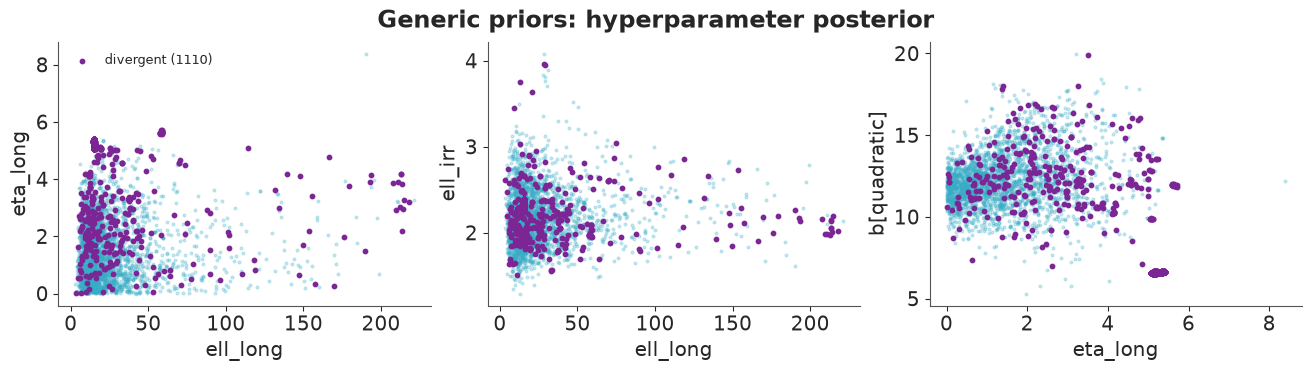

In [18]:
def plot_hyper_pairs(idata, title):
    post = az.extract(idata, var_names=["ell_long", "eta_long", "ell_irr", "eta_irr", "b"])
    div = idata.sample_stats["diverging"].stack(sample=("chain", "draw")).to_numpy()
    pairs = [("ell_long", "eta_long"), ("ell_long", "ell_irr"), ("eta_long", "b")]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for ax, (vx, vy) in zip(axes, pairs):
        xv = post[vx].to_numpy()
        yv = post["b"].sel(poly="quadratic").to_numpy() if vy == "b" else post[vy].to_numpy()
        ax.scatter(xv[~div], yv[~div], s=4, alpha=0.25, color="C0")
        ax.scatter(xv[div], yv[div], s=10, color="C3", label=f"divergent ({div.sum()})")
        ax.set(xlabel=vx, ylabel="b[quadratic]" if vy == "b" else vy)
    axes[0].legend(fontsize=9)
    fig.suptitle(title)


plot_hyper_pairs(generic_idata, "Generic priors: hyperparameter posterior");

The sampler is telling us, loudly, that something is wrong. More than a quarter of the draws
are divergent, `r_hat` is between 1.1 and 1.6 for every hyperparameter, the ESS of the
trend coefficients and of `eta_long` is in single digits, and each draw needs hundreds of
leapfrog steps. The chains have not converged to anything; do not interpret these numbers.

The plots show what the data cannot decide - **who owns the slow variation**:

- `ell_long` is essentially its prior, from a few years to a couple of centuries. At the
  short end it overlaps the irregular component (middle panel: both lengthscales can be a
  few years). At the long end an `ExpQuad` GP *is* a low-order polynomial over a 58-year
  window, so it overlaps the quadratic.
- `eta_long` runs from zero to beyond 5 ppm, and the trend coefficients go with it (right
  panel): the more amplitude the long component is given, the less the quadratic is pinned
  down. At `eta_long` near zero the long component is switched off and its coefficients
  are free to wander over their whole prior - the neck of a funnel.
- Divergent draws (dark) are all over the place, and tight isolated clumps of them are
  chains that got stuck.

The likelihood only sees the **sum** `trend + long + irregular`. Hand 1 ppm of slow wiggle
from one component to another and the fit does not change at all; only the priors notice.
With vague priors that is a long, flat, curved ridge in a 130-dimensional space - the
additive-model version of the non-identifiability you met with two intercepts in a
regression. It is not a sampler problem, and `target_accept=0.99` is not the answer.

## Task 4 · Tame it with priors

Without removing a component, and without heroic sampler settings (a moderate
`target_accept` is fine), make the decomposition identifiable **through priors alone**.
Every prior should be one you can defend to the analyst in physical units (years, ppm).

**Deliver**
1. Your priors and the argument for each.
2. Clean diagnostics.
3. A plot of the fitted components over the training period.
4. Is the seasonal cycle growing? Give the peak-to-trough range at the start and at the end
   of the training period, with uncertainty.

### Solution

The cure for "who owns what" is to **give each component a territory** and keep it there.

| parameter | prior | argument |
|---|---|---|
| `ell_irr` | InverseGamma, 90% in 1-5 years | El Niño episodes, eruptions and recessions last one to a few years. Below 1 year it would compete with the seasonal cycle and the noise. |
| `eta_irr` | HalfNormal(1) ppm | El Niño years add a few tenths of a ppm to a ppm. |
| `ell_long` | Gamma(mean 25, sd 5) years | "Decades". Clearly longer than the irregular component; clearly *shorter* than the 58-year window, beyond which it would just be another quadratic. |
| `eta_long` | Gamma(mean 1.5, sd 0.5) ppm | Task 0 showed decade-to-decade changes in growth that a constant acceleration cannot match, so an amplitude of **zero is not plausible** - and neither is 5 ppm. A Gamma with shape 9 has no mass at zero: that closes the funnel. |

The second and fourth rows matter most. A `HalfNormal` has its mode at zero, which is a
sensible default for "this effect may not exist". Here we *know* the effect exists, and
saying so is worth more than any sampler setting. The remaining ridge between `b` and
`long` is now short enough for NUTS; a slightly higher `target_accept` cleans up the last
few divergences.

In [19]:
structural_model = build_structural(train, "informed")
with freeze_dims_and_data(structural_model):
    structural_idata = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED)

sampler_report(structural_idata)
az.summary(structural_idata, var_names=HYPERS, ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [beta_drift, beta_seas, eta_irr, ell_irr, irregular_hsgp_coeffs, eta_long, ell_long, long_hsgp_coeffs, b, sigma]


divergences: 0 of 4000 draws;  mean leapfrog steps per draw: 498


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b[const],-0.03,1.53,-3.03,2.90,448.72,687.70,1.01,0.07,0.06
b[linear],48.09,1.29,45.74,50.65,691.89,925.70,1.00,0.05,0.04
b[quadratic],12.60,1.52,9.90,15.51,612.05,807.04,1.00,0.06,0.04
ell_long,23.27,5.22,14.09,33.02,1367.68,2065.07,1.00,0.14,0.08
eta_long,1.57,0.52,0.68,2.55,857.09,1487.68,1.00,0.02,0.01
ell_irr,1.53,0.23,1.10,1.96,1445.51,2345.33,1.00,0.01,0.00
eta_irr,0.73,0.13,0.50,0.99,946.28,1422.80,1.00,0.00,0.00
sigma,0.29,0.01,0.27,0.30,3428.56,2522.09,1.00,0.00,0.00


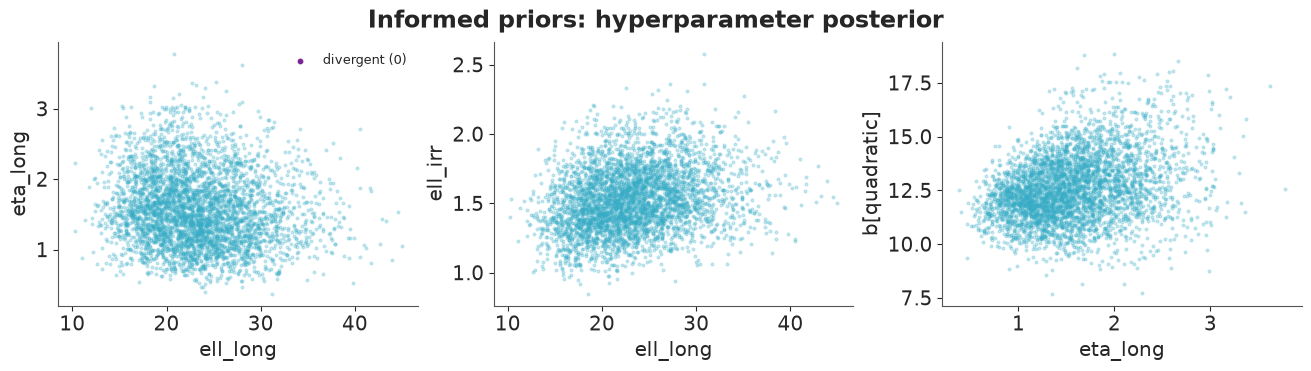

In [20]:
plot_hyper_pairs(structural_idata, "Informed priors: hyperparameter posterior");

seasonal peak-to-trough in 1960: 5.81 ppm, 90% interval [5.67 5.96]
seasonal peak-to-trough in 2015: 6.83 ppm, 90% interval [6.69 6.98]
ratio 2015 / 1960: 1.176, 90% interval [1.131 1.221]


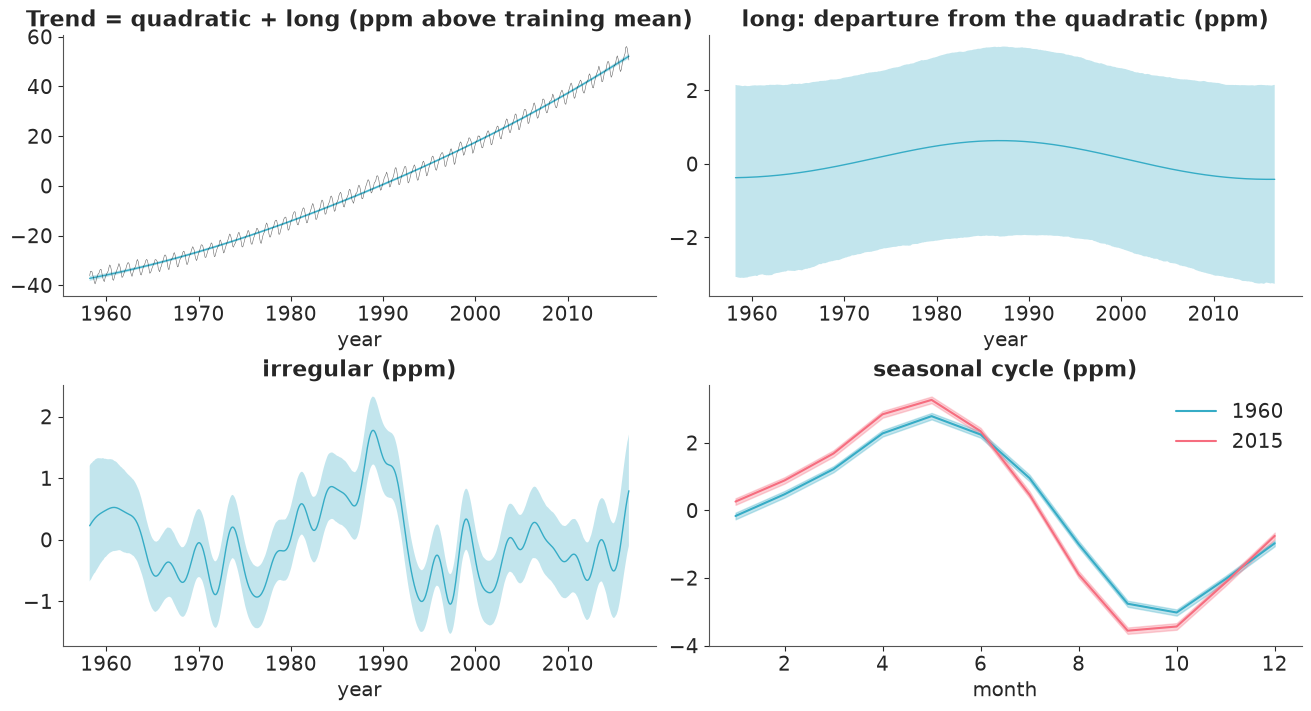

In [21]:
def band(da, prob=0.9):
    lo, hi = da.quantile([(1 - prob) / 2, (1 + prob) / 2], dim=("chain", "draw")).to_numpy()
    return da.mean(("chain", "draw")).to_numpy(), lo, hi


post = structural_idata.posterior
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
panels = [("trend", "Trend = quadratic + long (ppm above training mean)"),
          ("long", "long: departure from the quadratic (ppm)"),
          ("irregular", "irregular (ppm)")]
for ax, (name, title) in zip(axes.flat, panels):
    mean, lo, hi = band(post[name])
    ax.fill_between(train.t, lo, hi, alpha=0.3)
    ax.plot(train.t, mean, lw=1)
    ax.set(title=title, xlabel="year")
axes[0, 0].plot(train.t, train.ppm - PPM_MEAN, color="k", lw=0.4, alpha=0.6)

seasonal_draws = post["seasonal"].stack(sample=("chain", "draw")).transpose("sample", "obs").to_numpy()
ranges = {}
for year, color in [(1960, "C0"), (2015, "C1")]:
    rows = (train.year == year).to_numpy()
    lo, hi = np.quantile(seasonal_draws[:, rows], [0.05, 0.95], axis=0)
    axes[1, 1].fill_between(np.arange(1, 13), lo, hi, color=color, alpha=0.3)
    axes[1, 1].plot(np.arange(1, 13), seasonal_draws[:, rows].mean(axis=0), color=color, label=str(year))
    ranges[year] = seasonal_draws[:, rows].max(axis=1) - seasonal_draws[:, rows].min(axis=1)
axes[1, 1].set(title="seasonal cycle (ppm)", xlabel="month")
axes[1, 1].legend()

for year, r in ranges.items():
    print(f"seasonal peak-to-trough in {year}: {r.mean():.2f} ppm, 90% interval {np.quantile(r, [0.05, 0.95]).round(2)}")
ratio = ranges[2015] / ranges[1960]
print(f"ratio 2015 / 1960: {ratio.mean():.3f}, 90% interval {np.quantile(ratio, [0.05, 0.95]).round(3)}")

In [22]:
assert h.check("task4", sigma=post["sigma"].mean(), ell_irr=post["ell_irr"].mean())

- PASS `sigma` = 0.2863 is consistent with the reference solution.
- PASS `ell_irr` = 1.529 is consistent with the reference solution.

No divergences, `r_hat` at most 1.01, and the hyperparameter clouds are compact blobs
instead of funnels. The model is still not cheap - several hundred leapfrog steps per draw -
and the trend coefficients `b` keep the lowest ESS (several hundred): some ridge between
the quadratic and `long` is still there and always will be. The priors have made it short,
not removed it.

You can see that ridge in the top-right panel. On its own, `long` is barely identified: a
faint hump of about half a ppm in the 1980s inside a band of ±2.5 ppm, because whatever
`long` does the quadratic can undo. This is harmless, because everything we report depends
on their **sum**, `trend`, which is pinned down to a hair's breadth (top-left panel). What
`long` contributes is not a story about the past but **humility about the future**: beyond
the data, the trend is "the quadratic, give or take a smooth departure of a ppm or two".

`irregular` does tell a story: bumps one to three years wide, mostly within ±1 ppm. The
largest feature is a climb to almost +2 ppm at the end of the 1980s followed by a drop to
-1 ppm in the early 1990s - the years after the Pinatubo eruption and the collapse of the
Soviet economy are the usual suspects. The noise sd of a monthly mean is about 0.3 ppm.

And the seasonal cycle *is* growing: from 5.8 ppm peak-to-trough in 1960 to 6.8 ppm in
2015, an increase of about 18% (90% interval 13-22%). This is an established finding,
usually attributed to more vigorous plant growth in the northern hemisphere.

## Task 5 · Would it have worked? Hold-out evaluation

**Deliver**
1. A forecast plot for the hold-out period with a 90% predictive band, against the truth.
2. A table with RMSE for both baselines, the stationary GP and the structural model, plus
   coverage of the 50% and 90% predictive intervals for the two Bayesian models.
3. An honest paragraph for the analyst: is the model accurate? Is it calibrated? How much
   can 120 months of hold-out data tell you about calibration, given how forecast errors
   behave over time?

Sampling: [y]


lag-1 autocorrelation of the forecast errors: 0.79


,RMSE,coverage 50%,width 50% at 10 yr,coverage 90%,width 90% at 10 yr
seasonal naive,15.52,NaN,NaN,NaN,NaN
seasonal naive + drift,2.06,NaN,NaN,NaN,NaN
stationary GP,3.19,0.46,6.70,0.97,17.23
structural model,0.74,0.71,2.51,1.00,6.15


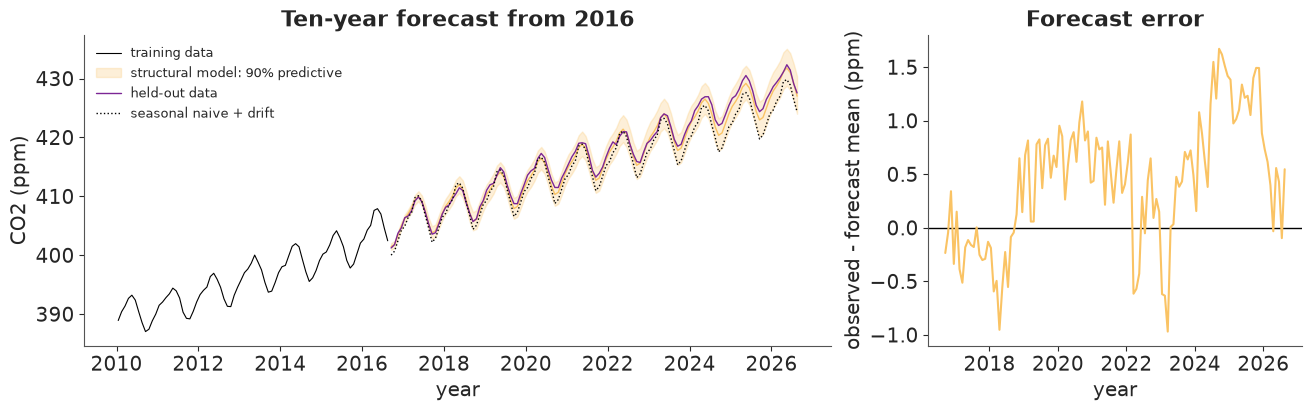

In [23]:
structural_pred = predict(structural_model, structural_idata, test.t.to_numpy(), ["y", "trend"])
structural_y = structural_pred["y"] + PPM_MEAN
structural_scores = holdout_scores(structural_y)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(train.t[train.t > 2010], train.ppm[train.t > 2010], color="k", lw=0.8, label="training data")
plot_forecast(test.t, structural_y, axes[0], color="C2", label="structural model")
axes[0].plot(test.t, test.ppm, color="C3", lw=1, label="held-out data")
axes[0].plot(test.t, naive_drift, color="k", ls=":", lw=1, label="seasonal naive + drift")
axes[0].set(xlabel="year", ylabel="CO2 (ppm)", title="Ten-year forecast from 2016", xticks=range(2010, 2027, 2))
axes[0].legend(fontsize=9)

error = test.ppm.to_numpy() - structural_y.mean(axis=0)
axes[1].axhline(0, color="k", lw=1)
axes[1].plot(test.t, error, color="C2")
axes[1].set(xlabel="year", ylabel="observed - forecast mean (ppm)", title="Forecast error")

lag1 = np.corrcoef(error[:-1], error[1:])[0, 1]
print(f"lag-1 autocorrelation of the forecast errors: {lag1:.2f}")
score_table.loc["structural model"] = pd.Series(structural_scores)
score_table.round(2)

In [24]:
assert h.check("task5", rmse=structural_scores["RMSE"], coverage90=structural_scores["coverage 90%"])

- PASS `rmse` = 0.7358 is consistent with the reference solution.
- PASS `coverage90` = 1 is consistent with the reference solution.

**Accurate?** Yes. Ten years out, with no access to the data, the structural model's RMSE
is 0.7 ppm: about a third of the drift baseline and a quarter of the stationary GP. It gets
the seasonal cycle right, and the forecast error stays within about ±1.7 ppm all decade.

**Calibrated?** Conservative. The 90% band contains every one of the 120 held-out months
and the 50% band contains about 70% of them. The model was *less* sure than it needed to
be: its prior allows departures from the quadratic (`eta_long`) that, in this particular
decade, mostly did not happen. For a policy briefing, erring in this direction is the right
way round - and a 6 ppm band after ten years is a far better position than the stationary
GP's 17 ppm.

**But do not over-read the coverage numbers.** The forecast errors are strongly
autocorrelated (0.8 from one month to the next): once the forecast trend is a little low,
it stays low for years - look at the right-hand panel. So 120 months are nowhere near 120
independent trials; for the trend they are closer to a handful. A single hold-out decade
can expose a broken model (it would have exposed a linear trend at once), but it cannot
certify the width of a 90% interval. Rolling-origin evaluation (refit in 1986, 1996,
2006, ...) is the honest next step; see "Going further".

## Task 6 · Answer the analyst

Refit your structural model on **all** the data.

**Deliver**
1. The posterior predictive distribution of the **first month in which the monthly mean
   exceeds 450 ppm**: a plot, the median, and statements of the form "with probability p by
   the end of year Y". Use predictive draws of the *observable* monthly mean, not the trend.
2. The growth rate of the **trend** (no seasonal, no irregular component), averaged over the
   last ten years of data, against the same for January 1960 - January 1970, in ppm/yr, and
   their ratio - all with 94% intervals.
3. Three sentences for the slide, and one caveat the analyst must not leave out.

In [25]:
final_model = build_structural(co2, "informed")
with freeze_dims_and_data(final_model):
    final_idata = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED)

sampler_report(final_idata)
az.summary(final_idata, var_names=HYPERS, ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [beta_drift, beta_seas, eta_irr, ell_irr, irregular_hsgp_coeffs, eta_long, ell_long, long_hsgp_coeffs, b, sigma]


divergences: 0 of 4000 draws;  mean leapfrog steps per draw: 527


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b[const],-0.00,1.45,-2.88,2.70,417.25,583.25,1.01,0.07,0.05
b[linear],48.22,1.09,46.16,50.40,841.63,1049.97,1.00,0.04,0.03
b[quadratic],12.75,1.17,10.71,15.05,591.59,681.94,1.01,0.05,0.04
ell_long,22.40,5.05,13.61,31.81,1619.73,2353.89,1.00,0.12,0.07
eta_long,1.59,0.51,0.74,2.59,1342.21,1743.10,1.00,0.01,0.01
ell_irr,1.47,0.22,1.07,1.88,1544.86,2121.45,1.00,0.01,0.00
eta_irr,0.71,0.12,0.50,0.95,1173.57,1984.65,1.01,0.00,0.00
sigma,0.29,0.01,0.28,0.30,3869.25,2296.44,1.00,0.00,0.00


In [26]:
start = pd.Period(year=int(co2.year.iloc[-1]), month=int(co2.month.iloc[-1]), freq="M") + 1
future_months = pd.period_range(start, "2040-12", freq="M")
t_future = (future_months.year + (future_months.month - 0.5) / 12).to_numpy()  # NOAA's mid-month convention
t_all = np.concatenate([co2.t.to_numpy(), t_future])

final_pred = predict(final_model, final_idata, t_all, ["y", "trend"])
y_future = final_pred["y"][:, len(co2):] + PPM_MEAN  # (draws, future months)
trend_all = final_pred["trend"] + PPM_MEAN

# first exceedance, draw by draw
exceeds = y_future > THRESHOLD
print(f"share of draws that never exceed {THRESHOLD:.0f} ppm by 2040: {1 - exceeds.any(axis=1).mean():.4f}")
first_idx = exceeds.argmax(axis=1)  # index of the first True in each draw
first_t = t_future[first_idx]
first_month = future_months[first_idx]

pmf = pd.Series(first_month.astype(str)).value_counts(normalize=True).sort_index()
median_month = future_months[int(np.median(first_idx))]
print(f"median first exceedance: {median_month} (decimal year {np.median(first_t):.2f}); "
      f"90% interval {future_months[int(np.quantile(first_idx, 0.05))]} to {future_months[int(np.quantile(first_idx, 0.95))]}")
by_year = pd.Series(first_month.year).value_counts(normalize=True).sort_index().cumsum()
print("\nP(first exceedance by the end of year):")
print(by_year.round(3).to_string())

Sampling: [y]


share of draws that never exceed 450 ppm by 2040: 0.0000
median first exceedance: 2033-04 (decimal year 2033.29); 90% interval 2032-05 to 2034-04

P(first exceedance by the end of year):
2031    0.000
2032    0.156
2033    0.878
2034    0.999
2035    1.000


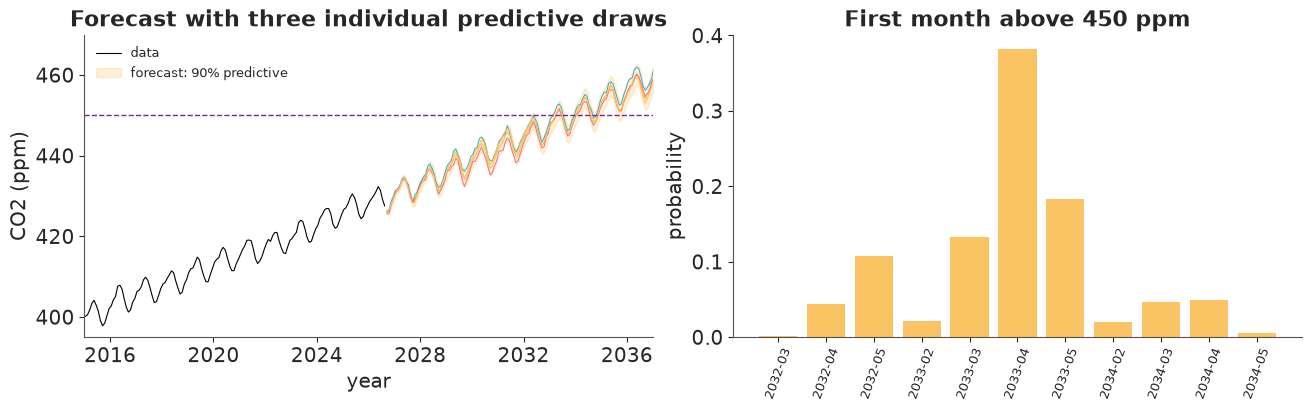

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(co2.t[co2.t > 2015], co2.ppm[co2.t > 2015], color="k", lw=0.8, label="data")
plot_forecast(t_future, y_future, axes[0], color="C2", label="forecast")
axes[0].plot(t_future, y_future[:3].T, lw=0.7)
axes[0].axhline(THRESHOLD, color="C3", ls="--", lw=1)
axes[0].set(xlabel="year", ylabel="CO2 (ppm)", xlim=(2015, 2037), ylim=(395, 470), xticks=range(2016, 2037, 4),
            title="Forecast with three individual predictive draws")
axes[0].legend(fontsize=9, loc="upper left")

shown = pmf[pmf > 0.002]
axes[1].bar(range(len(shown)), shown.values, color="C2")
axes[1].set_xticks(range(len(shown)), shown.index, rotation=70, fontsize=9)
axes[1].set(ylabel="probability", title="First month above 450 ppm");

In [28]:
t_obs = co2.t.to_numpy()
i_1960 = int(np.argmin(np.abs(t_obs - 1960.04)))  # January 1960
i_1970 = i_1960 + 120
i_last = len(co2) - 1
i_prev = i_last - 120

growth_1960s = (trend_all[:, i_1970] - trend_all[:, i_1960]) / (t_obs[i_1970] - t_obs[i_1960])
growth_recent = (trend_all[:, i_last] - trend_all[:, i_prev]) / (t_obs[i_last] - t_obs[i_prev])
growth = pd.DataFrame({"1960-1970": growth_1960s, "last 10 years": growth_recent,
                       "ratio": growth_recent / growth_1960s})
summary = growth.agg(["mean", lambda s: s.quantile(0.03), lambda s: s.quantile(0.97)]).T
summary.columns = ["mean", "3%", "97%"]
print("trend growth rate (ppm/yr)")
summary.round(2)

trend growth rate (ppm/yr)


,mean,3%,97%
1960-1970,0.93,0.85,1.02
last 10 years,2.53,2.42,2.64
ratio,2.71,2.44,3.03


In [29]:
assert h.check("task6", first_exceed_median=np.median(first_t),
               growth_1960s=growth_1960s.mean(), growth_recent=growth_recent.mean())

- PASS `first_exceed_median` = 2033 is consistent with the reference solution.
- PASS `growth_1960s` = 0.9339 is consistent with the reference solution.
- PASS `growth_recent` = 2.528 is consistent with the reference solution.

**For the slide**

1. Monthly mean CO2 at Mauna Loa will most likely exceed 450 ppm for the first time in
   **spring 2033** (median: April 2033); there is roughly a one-in-six chance that it happens
   a year earlier, and it is all but certain by the end of 2034.
2. Whatever the year, the crossing happens **between February and May**: the seasonal peak
   adds about 3 ppm to the trend, which is more than a year's growth. That is why the
   distribution comes in annual lumps, and why a trend-only calculation gets the date wrong.
3. CO2 is now rising at about **2.5 ppm per year, against 0.9 ppm per year in the 1960s** -
   between two and a half and three times as fast.

**The caveat.** This is a statistical extrapolation of 68 years of steadily accelerating
emissions. The interval reflects what the *past* says about departures from a smooth
accelerating trend; it contains no scenario in which the world decarbonises quickly (or a
major carbon sink fails). It answers "when, if things go on as they have" - which, seven
years out, is a reasonable question. For 2060 it would not be.

Notice also what made the first answer possible at all: the distribution of the crossing
date is lumpy and seasonal, and no formula gives it. We simulated futures - trend,
seasonal cycle, irregular bumps and noise together - and *counted*.

## Going further

- **Does the slow-departure component earn its place?** Drop it, refit on the training
  period and repeat Task 5. What happens to the RMSE and to the coverage of the 90% interval, and why?
- **Rolling-origin evaluation.** Refit with training data ending in 1986, 1996 and 2006 and
  forecast ten years each time. Does the 90% interval cover about 90% of the time *across
  origins*? Would you widen or narrow the prior on the amplitude of the slow departures?
- **Marginalise the coefficients.** Given the hyperparameters, this model is linear and
  Gaussian in all ~130 coefficients, so they can be integrated out analytically, leaving NUTS
  a handful of hyperparameters. Implement the marginal likelihood with the Woodbury identity
  (cost $O(nm^2)$) and compare speed and results.
- **A physical covariate.** The irregular component should correlate with El Niño. Find an
  ENSO index (e.g. NOAA's ONI), lag it by a few months, add it as a regressor and see how
  much of your irregular component it absorbs.

In [30]:
h.progress()

**C08**: 0/21 hints used, 13/13 checks passed.